In [1]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import seaborn as sns

In [2]:
docking_df = pd.read_csv("../docking/results.csv", names=["zincid", "smiles", "docking_score"])
docking_df = docking_df.set_index("smiles")
mmpbsa_df = pd.read_csv("../mmpbsa_dg_en_gb_avg.csv")
mmpbsa_df = mmpbsa_df.set_index("smiles")
df = mmpbsa_df.join(docking_df, how="inner")
df.describe()

,target,docking_score
count,58668.000000,58668.000000
mean,-31.481852,-8.338669
std,5.514605,0.931581
min,-54.684265,-11.909000
25%,-35.167797,-9.094000
50%,-31.581463,-8.253000
75%,-27.879468,-7.611000
max,-9.219612,-5.637000


In [179]:
df["scaffold"] = df.index.map(MurckoScaffold.MurckoScaffoldSmiles)
df["scaffold"].value_counts()

scaffold
c1ccc2[nH]ccc2c1                               16432
O=C(CCc1c[nH]c2ccccc12)Oc1ccccc1                8111
O=C(CCc1c[nH]c2ccccc12)OC1CCCCC1                2578
O=C(CCc1cc[nH]c1)Oc1ccccc1                      1174
O=C(CCc1c(-c2ccccc2)[nH]c2ccccc12)Oc1ccccc1      930
                                               ...  
O=C(OCC1CCc2nccn21)c1cc2ccccc2[nH]1                1
O=C(OCCCc1ncno1)c1cc2ccccc2[nH]1                   1
O=C(OCc1cc2n(n1)CCC2)c1cc2ccccc2[nH]1              1
O=C(COc1cccc2c1OCCC2)C(=O)c1c[nH]c2ccccc12         1
O=C(OCc1ccn(C2CC2)n1)c1cc2ccccc2[nH]1              1
Name: count, Length: 2919, dtype: int64

<Axes: xlabel='count', ylabel='Count'>

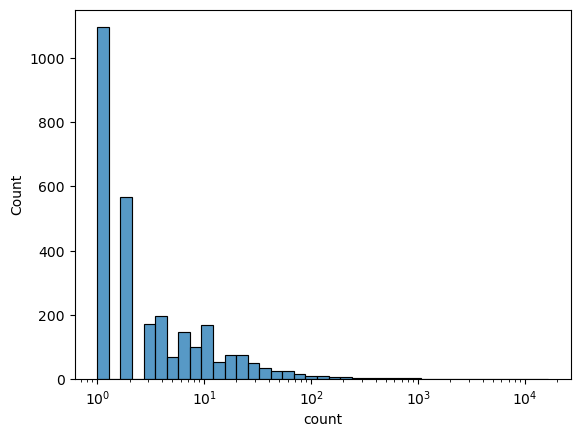

In [180]:
sns.histplot(df, x=df["scaffold"].value_counts(), log_scale=True)

We see that most scaffolds appear less then 100 times. The most common scaffold appears ~17k times

In [181]:

def proportional_sampling(df, group_column, total_samples):
    """
    Samples proportionally the first k_i entries from each group, where k_i is determined
    by the size of the group and such that sum k_i = total_samples.
    """
    group_sizes = df[group_column].value_counts()
    
    proportions = group_sizes / group_sizes.sum()
    # Exact proportions
    sample_sizes = (proportions * total_samples).astype(float)
    
    # Approximate proportion
    int_samples = sample_sizes.astype(int)
    remainders = sample_sizes - int_samples

    # Does not yet sum up to total_samples
    # we will distribute the remaining samples over the 
    # groups with the largest remainders
    remaining = 1000 - int_samples.sum()
    indices = remainders.nlargest(remaining).index
    int_samples.loc[indices] += 1
    assert int_samples.sum() == total_samples

    result = df.groupby(group_column, group_keys=False)[df.columns].apply(  # [df.columns] to retain the group columns
        lambda group: group.head(int_samples[group.name])
    )

    return result

In [191]:
sorted_df = df.sort_values(by="docking_score")
sample = proportional_sampling(sorted_df, "scaffold", 1000)
sample.to_csv("dataset.csv")
sample

,target,zincid,docking_score,scaffold
smiles,,,,
CC(C)(C)OC(=O)[C@@H]1C[C@H]2CCCC[C@@H]2N1,-27.189431,ZINCgs000000Jry7,-7.476,C1CCC2NCCC2C1
C[C@@]1(C(=O)O)C[C@H]2CCCC[C@@H]2N1,-19.106444,ZINCdj000001nWRn,-7.222,C1CCC2NCCC2C1
C=C1[C@@H](OC(=O)[C@@H](Cc2c[nH]c3c(C)cccc23)NC(C)=O)C[C@H]2C[C@@H]1C2(C)C,-36.134548,ZINCtK00000004Un,-10.270,C=C1C2CC(C2)CC1OC(=O)CCc1c[nH]c2ccccc12
C=C1CCC[C@@H]1OC(=O)CCc1c[nH]c2cccc(C)c12,-31.771035,ZINClK000003V6av,-9.666,C=C1CCCC1OC(=O)CCc1c[nH]c2ccccc12
C=C1CCCC[C@H]1OC(=O)CCc1c(-c2ccccc2)[nH]c2c(Cl)cccc12,-45.474743,ZINCsV000003Xh3H,-9.844,C=C1CCCCC1OC(=O)CCc1c(-c2ccccc2)[nH]c2ccccc12
...,...,...,...,...
C=C=C[C@@H](C)C(=O)Oc1cc(C)c(Cl)c(C)c1,-25.534635,ZINChI000001hHl6,-8.240,c1ccccc1
C=C=C[C@H](C)C(=O)Oc1cc(C)c(Cl)c(C)c1,-30.652399,ZINChI000001hHmy,-8.185,c1ccccc1
CC(C)=CCCOc1cc(C)c(Cl)c(C)c1Cl,-33.669220,ZINChU00000EhIa2,-8.121,c1ccccc1


<Axes: xlabel='count', ylabel='Count'>

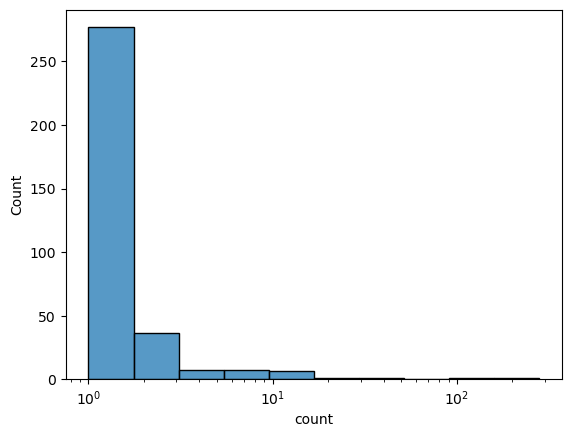

In [183]:
sns.histplot(sample, x=sample["scaffold"].value_counts(), log_scale=True)

In [184]:
sample.groupby("scaffold").describe()

target                       \
                                               count       mean       std   
scaffold                                                                    
C1CCC2NCCC2C1                                    2.0 -23.147937  5.715535   
C=C1C2CC(C2)CC1OC(=O)CCc1c[nH]c2ccccc12          1.0 -36.134548       NaN   
C=C1CCCC1OC(=O)CCc1c[nH]c2ccccc12                1.0 -31.771035       NaN   
C=C1CCCCC1OC(=O)CCc1c(-c2ccccc2)[nH]c2ccccc12    1.0 -45.474743       NaN   
C=C1CCCCC1OC(=O)CCc1c[nH]c2ccccc12               1.0 -36.840909       NaN   
...                                              ...        ...       ...   
c1ccc2c(CCNC3CCC3)c[nH]c2c1                      1.0 -36.070149       NaN   
c1ccc2c(CCNCC3CC3)c[nH]c2c1                      1.0 -31.619527       NaN   
c1ccc2c(c1)CCN2                                 10.0 -29.332080  4.390348   
c1ccccc1                                         6.0 -27.650115  4.420818   
c1cncc(-c2cccc3cc[nH]c23)c1                      1.0 -36.671867       NaN   

                                                                     \
                                                     min        25%   
scaffold                                                              
C1CCC2NCCC2C1                                 -27.189431 -25.168684   
C=C1C2CC(C2)CC1OC(=O)CCc1c[nH]c2ccccc12       -36.134548 -36.134548   
C=C1CCCC1OC(=O)CCc1c[nH]c2ccccc12             -31.771035 -31.771035   
C=C1CCCCC1OC(=O)CCc1c(-c2ccccc2)[nH]c2ccccc12 -45.474743 -45.474743   
C=C1CCCCC1OC(=O)CCc1c[nH]c2ccccc12            -36.840909 -36.840909   
...                                                  ...        ...   
c1ccc2c(CCNC3CCC3)c[nH]c2c1                   -36.070149 -36.070149   
c1ccc2c(CCNCC3CC3)c[nH]c2c1                   -31.619527 -31.619527   
c1ccc2c(c1)CCN2                               -38.582728 -30.731733   
c1ccccc1                                      -33.669220 -30.352806   
c1cncc(-c2cccc3cc[nH]c23)c1                   -36.671867 -36.671867   

                                                                     \
                                                     50%        75%   
scaffold                                                              
C1CCC2NCCC2C1                                 -23.147937 -21.127191   
C=C1C2CC(C2)CC1OC(=O)CCc1c[nH]c2ccccc12       -36.134548 -36.134548   
C=C1CCCC1OC(=O)CCc1c[nH]c2ccccc12             -31.771035 -31.771035   
C=C1CCCCC1OC(=O)CCc1c(-c2ccccc2)[nH]c2ccccc12 -45.474743 -45.474743   
C=C1CCCCC1OC(=O)CCc1c[nH]c2ccccc12            -36.840909 -36.840909   
...                                                  ...        ...   
c1ccc2c(CCNC3CCC3)c[nH]c2c1                   -36.070149 -36.070149   
c1ccc2c(CCNCC3CC3)c[nH]c2c1                   -31.619527 -31.619527   
c1ccc2c(c1)CCN2                               -29.245535 -27.527131   
c1ccccc1                                      -27.494332 -25.239516   
c1cncc(-c2cccc3cc[nH]c23)c1                   -36.671867 -36.671867   

                                                         docking_score  \
                                                     max         count   
scaffold                                                                 
C1CCC2NCCC2C1                                 -19.106444           2.0   
C=C1C2CC(C2)CC1OC(=O)CCc1c[nH]c2ccccc12       -36.134548           1.0   
C=C1CCCC1OC(=O)CCc1c[nH]c2ccccc12             -31.771035           1.0   
C=C1CCCCC1OC(=O)CCc1c(-c2ccccc2)[nH]c2ccccc12 -45.474743           1.0   
C=C1CCCCC1OC(=O)CCc1c[nH]c2ccccc12            -36.840909           1.0   
...                                                  ...           ...   
c1ccc2c(CCNC3CCC3)c[nH]c2c1                   -36.070149           1.0   
c1ccc2c(CCNCC3CC3)c[nH]c2c1                   -31.619527           1.0   
c1ccc2c(c1)CCN2                               -21.310909          10.0   
c1ccccc1                                      -21.449265           6.0   
c1cncc(-c2cccc3

<Axes: xlabel='docking_score', ylabel='Count'>

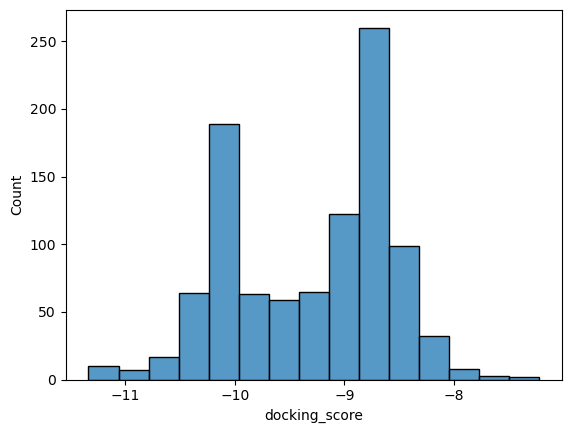

In [185]:
sns.histplot(sample, x="docking_score")

<Axes: xlabel='target', ylabel='Count'>

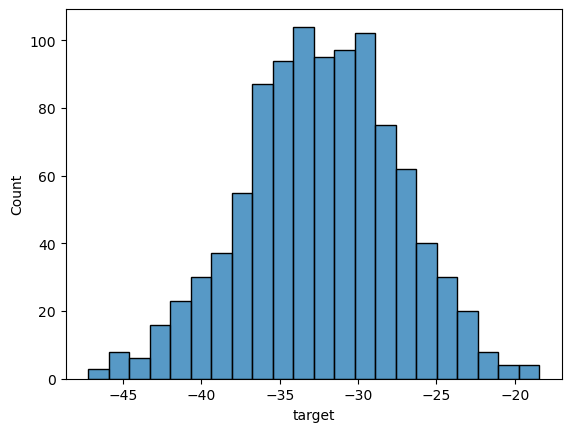

In [186]:
sns.histplot(sample, x="target")

In [187]:
from rdkit.Chem import rdFingerprintGenerator

mpfgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
molecules = sample.index.map(Chem.MolFromSmiles).to_list()
X = np.vstack(list(map(mpfgen.GetFingerprintAsNumPy, molecules)))

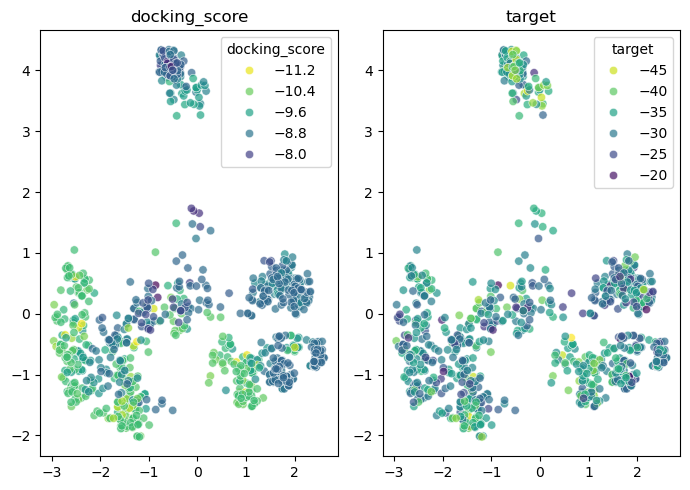

In [188]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings = pca.fit_transform(X)


fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(7, 5))

sns.scatterplot(sample, x=embeddings[:, 0], y=embeddings[:, 1], hue="docking_score", palette="viridis_r", ax=ax1, alpha=0.7)
sns.scatterplot(sample, x=embeddings[:, 0], y=embeddings[:, 1], hue="target", palette="viridis_r", ax=ax2, alpha=0.7)

ax1.set_title("docking_score")
ax2.set_title("target")

fig.tight_layout()

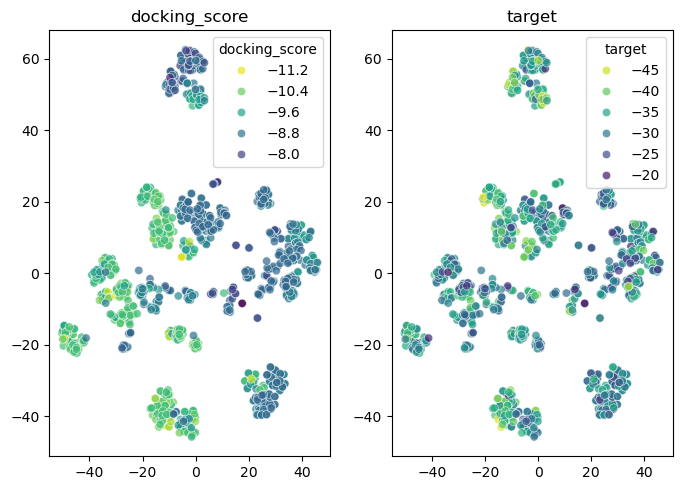

In [189]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
embeddings = tsne.fit_transform(X)


fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(7, 5))

sns.scatterplot(sample, x=embeddings[:, 0], y=embeddings[:, 1], hue="docking_score", palette="viridis_r", ax=ax1, alpha=0.7)
sns.scatterplot(sample, x=embeddings[:, 0], y=embeddings[:, 1], hue="target", palette="viridis_r", ax=ax2, alpha=0.7)

ax1.set_title("docking_score")
ax2.set_title("target")

fig.tight_layout()

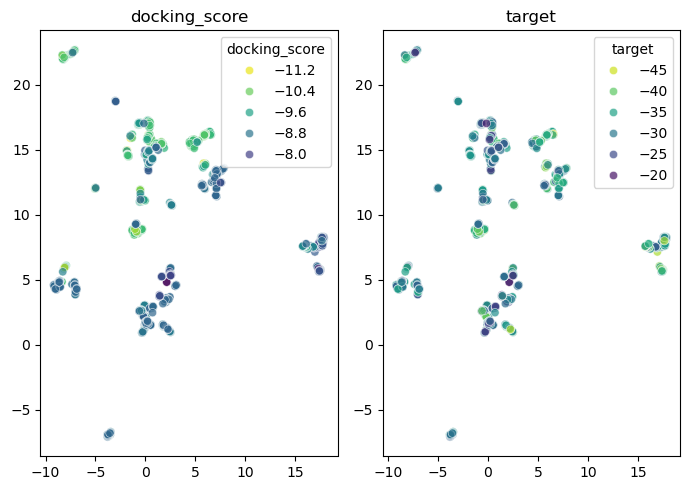

In [190]:
from umap import UMAP

umap_ = UMAP(n_components=2)
embeddings = umap_.fit_transform(X)


fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(7, 5))

sns.scatterplot(sample, x=embeddings[:, 0], y=embeddings[:, 1], hue="docking_score", palette="viridis_r", ax=ax1, alpha=0.7)
sns.scatterplot(sample, x=embeddings[:, 0], y=embeddings[:, 1], hue="target", palette="viridis_r", ax=ax2, alpha=0.7)

ax1.set_title("docking_score")
ax2.set_title("target")

fig.tight_layout()